In [2]:
# PANDAS FUNDAMENTALS
# Creating a data frame
import pandas as pd
data = {
    "Name": ["John", "Mary", "Peter", "Jane", "David",
             "Ann", "Brian", "Lucy", "Kevin", "Sarah"],

    "Age": [20, 22, 21, 19, 23, 20, 24, 21, 22, 20],

    "Score": [65, 78, 55, 90, 72, 88, 60, 95, 70, 82],

    "Study_Hours": [4, 6, 3, 8, 5, 7, 4, 9, 5, 6]
}
df = pd.DataFrame(data)
df

,Name,Age,Score,Study_Hours
0,John,20,65,4
1,Mary,22,78,6
2,Peter,21,55,3
3,Jane,19,90,8
4,David,23,72,5
5,Ann,20,88,7
6,Brian,24,60,4
7,Lucy,21,95,9
8,Kevin,22,70,5
9,Sarah,20,82,6


In [7]:
# Displaying the first five rows
head=df.head(5)
print(head)
print('----------------------------------------------------')
# Displaying the last 3 rows
tail=df.tail(3)
print(tail)
print('----------------------------------------------------')
# Finding the shape of the dataframe
shape=df.shape
print(shape)
print('----------------------------------------------------')
# Getting basic information about the Dataframe
info=df.info()
print(info)
print('----------------------------------------------------')
# Getting description about the Dataframe
describe=df.describe()
print(describe)

    Name  Age  Score  Study_Hours
0   John   20     65            4
1   Mary   22     78            6
2  Peter   21     55            3
3   Jane   19     90            8
4  David   23     72            5
----------------------------------------------------
    Name  Age  Score  Study_Hours
7   Lucy   21     95            9
8  Kevin   22     70            5
9  Sarah   20     82            6
----------------------------------------------------
(10, 4)
----------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         10 non-null     str  
 1   Age          10 non-null     int64
 2   Score        10 non-null     int64
 3   Study_Hours  10 non-null     int64
dtypes: int64(3), str(1)
memory usage: 452.0 bytes
None
----------------------------------------------------
             Age      Score  Study_Hours
count  10.000

In [17]:
# Filtering
# Students who scored above 80
above80=df[df['Score']>80]
print(above80)
print('---------------------------------------------------------------------------------------------')
# Students who studied more than 5 hours
hours5=df[df['Study_Hours']>5]
print(hours5)
print('----------------------------------------------------')
# Students aged 21 years and older
age21=df[df['Age']>=21]
print(age21)
print('----------------------------------------------------')
# Student who scored above 70 and studied for more than 5 hours
stud=df[(df['Score']>70)& (df['Study_Hours']>5)]
print(stud)

    Name  Age  Score  Study_Hours
3   Jane   19     90            8
5    Ann   20     88            7
7   Lucy   21     95            9
9  Sarah   20     82            6
---------------------------------------------------------------------------------------------
    Name  Age  Score  Study_Hours
1   Mary   22     78            6
3   Jane   19     90            8
5    Ann   20     88            7
7   Lucy   21     95            9
9  Sarah   20     82            6
----------------------------------------------------
    Name  Age  Score  Study_Hours
1   Mary   22     78            6
2  Peter   21     55            3
4  David   23     72            5
6  Brian   24     60            4
7   Lucy   21     95            9
8  Kevin   22     70            5
----------------------------------------------------
    Name  Age  Score  Study_Hours
1   Mary   22     78            6
3   Jane   19     90            8
5    Ann   20     88            7
7   Lucy   21     95            9
9  Sarah   20     

In [28]:
# Statistics with pandas
# Mean score
mean=df['Score'].mean()
print(f'MEAN SCORE: ',mean)
# Median Score
median=df['Score'].median()
print(f'MEDIAN SCORE: ',median)
# Mode score
mode=df['Score'].mode()
print(f'MODE SCORE: ',mode)
# Standard Deviation
std=round(df['Score'].std(),2)
print(f'STANDARD DEVIATION: ',std)
# Variance
var=round(df['Score'].var(),2)
print(f'VARIANCE: ',var)
#  Minimum score
min=df['Score'].min()
print(f'MINIMUM SCORE: ',min)
#  Maximum score
max=df['Score'].max()
print(f'MAXIMUM SCORE: ',max)

# Score Range
range=max-min
print(f'SCORE RANGE: ',range)

MEAN SCORE:  75.5
MEDIAN SCORE:  75.0
MODE SCORE:  0    55
1    60
2    65
3    70
4    72
5    78
6    82
7    88
8    90
9    95
Name: Score, dtype: int64
STANDARD DEVIATION:  13.37
VARIANCE:  178.72
MINIMUM SCORE:  55
MAXIMUM SCORE:  95
SCORE RANGE:  40


In [40]:
# THINKING LIKE DATA ANALYST
# A. What percentage of students scored above 70
# Student above 70
above70=df[df['Score']>70]
totalStudents=df['Name'].count()
percentage=(len(above70)/totalStudents)*100
print(f'Percentage: ',percentage, '%')

# What is the average study time
averageStudyingTime=df['Study_Hours'].mean()
print(f'AVERAGE STUDYING TIME: ',averageStudyingTime)

# Is there evidence that students who study more tend to score higher
correlation=df['Study_Hours'].corr(df['Score'])
print(f'Correlation: ',correlation)

Percentage:  60.0 %
AVERAGE STUDYING TIME:  5.7
Correlation:  0.9791899930411828


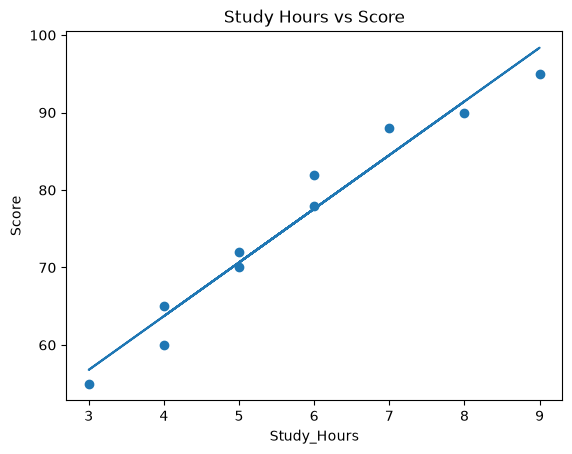

In [54]:
# Visualization
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(df['Study_Hours'],df['Score'])
m,b=np.polyfit(df['Study_Hours'],df['Score'],1)
plt.plot(df['Study_Hours'], m* df['Study_Hours'] +b )
plt.xlabel('Study_Hours')
plt.ylabel('Score')
plt.title('Study Hours vs Score')
plt.show()

In [50]:
# Which student has the highest score
student=df.loc[df['Score'].idxmax()]
print(f'Student: ',student['Name'])
print(f'Score: ',student['Score'])
print('---------------------------------------------------')
# Which student has the lowest score
student1=df.loc[df['Score'].idxmin()]
print(f'Student: ',student1['Name'])
print(f'Score: ', student1['Score'])

Student:  Lucy
Score:  95
---------------------------------------------------
Student:  Peter
Score:  55


In [70]:
# CHALLENGE 6
# Adding a new performance column
df['Performance']=np.where(
    df['Score']>70,
    'Pass',
    'Fail'
)
df
 # How many students passed and how many failed
passed=df[df['Performance']=='Pass']
print(f'Number of Student who passed: ',len(passed))

failed=df[df['Performance']=='Fail']
print(f'Number of student who failed: ',len(failed))

# Average score of student who failed
average_failed_score=failed['Score'].mean()
print(f'Average Failed Score: ',average_failed_score)
 # Average score of student who passed
average_passed_score=passed['Score'].mean()
print(f'Average Pass Score: ',round(average_passed_score,2))

Number of Student who passed:  6
Number of student who failed:  4
Average Failed Score:  62.5
Average Pass Score:  84.17
